In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
#Load the DF keeping Client, warehouse and product as the index
sales = pd.read_csv('Phase 0 - Sales.csv').set_index(["Client", "Warehouse", "Product"])
price = pd.read_csv('Phase 0 - Price.csv').set_index(["Client", "Warehouse", "Product"])

In [113]:
#explore the dataset
sales.head()

2020-07-06  2020-07-13  2020-07-20  2020-07-27  \
Client Warehouse Product                                                   
0      1         367             7.0         7.0         7.0         7.0   
                 639             0.0         0.0         0.0         0.0   
                 655            21.0        21.0        21.0        25.0   
                 1149            7.0         7.0         7.0         7.0   
                 1485            0.0         0.0         0.0         0.0   

                          2020-08-03  2020-08-10  2020-08-17  2020-08-24  \
Client Warehouse Product                                                   
0      1         367             7.0         7.0         7.0         7.0   
                 639             0.0         0.0         0.0         0.0   
                 655            35.0        35.0        35.0        35.0   
                 1149            7.0         7.0         7.0         7.0   
                 1485            0.0         0.0         0.0         0.0   

                          2020-08-31  2020-09-07  ...  2023-07-31  2023-08-07  \
Client Warehouse Product                          ...                           
0      1         367             7.0         7.0  ...         1.0         0.0   
                 639             0.0         0.0  ...         3.0         5.0   
                 655            35.0        35.0  ...         9.0         4.0   
                 1149            7.0         7.0  ...         1.0         1.0   
                 1485            0.0         0.0  ...        21.0        23.0   

                          2023-08-14  2023-08-21  2023-08-28  2023-09-04  \
Client Warehouse Product                                                   
0      1         367             1.0         0.0         1.0         1.0   
                 639             5.0         6.0         5.0         1.0   
                 655             2.0         9.0         8.0         6.0   
                 1149            1.0         0.0         2.0         2.0   
                 1485            2.0         1.0         1.0         2.0   

                          2023-09-11  2023-09-18  2023-09-25  2023-10-02  
Client Warehouse Product                                                  
0      1         367             0.0         0.0         7.0         0.0  
                 639             2.0         2.0        18.0         2.0  
                 655             0.0        17.0        21.0        37.0  
                 1149            2.0         1.0         0.0         1.0  
                 1485            0.0        22.0        10.0         6.0  

[5 rows x 170 columns]

In [133]:
#melt the original DFs and make the date a column value instead
sales = pd.melt(sales, var_name = 'Date', value_name = 'Sales', ignore_index = False).reset_index()
price = pd.melt(price, var_name = 'Date', value_name = 'Price', ignore_index = False).reset_index()

Lets begin with analyzing sales so we can understand the data

In [593]:
#Describe Sales information
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2559010 entries, 0 to 2559009
Data columns (total 5 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Client     int64         
 1   Warehouse  int64         
 2   Product    int64         
 3   Date       datetime64[ns]
 4   Sales      float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 97.6 MB


In [151]:
#describe the variables
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Client,2559010.0,19.758321,14.033295,0.0,6.0,18.0,30.0,46.0
Warehouse,2559010.0,173.188069,98.575040,0.0,79.0,162.0,265.0,338.0
Product,2559010.0,7180.340796,4109.389541,0.0,3676.0,7228.0,10727.0,14323.0
Sales,2559010.0,12.683722,101.185394,0.0,0.0,0.0,1.0,13681.0


In [157]:
sales.isna().sum() #find out if we have any missing data

Client       0
Warehouse    0
Product      0
Date         0
Sales        0
dtype: int64

Now, we can review the price information:

In [598]:
#describe the price dataset
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2559010 entries, 0 to 2559009
Data columns (total 5 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Client     int64  
 1   Warehouse  int64  
 2   Product    int64  
 3   Date       object 
 4   Price      float64
dtypes: float64(1), int64(3), object(1)
memory usage: 97.6+ MB


In [600]:
#describe the features of the price datset
price.describe().T

,count,mean,std,min,25%,50%,75%,max
Client,2559010.0,19.758321,14.033295,0.0,6.00,18.00,30.00,46.0
Warehouse,2559010.0,173.188069,98.575040,0.0,79.00,162.00,265.00,338.0
Product,2559010.0,7180.340796,4109.389541,0.0,3676.00,7228.00,10727.00,14323.0
Price,722573.0,76.209591,228.967099,0.0,17.73,27.99,51.19,10000.0


In [602]:
price.isna().sum() #find out if we have any missing data

Client             0
Warehouse          0
Product            0
Date               0
Price        1836437
dtype: int64

As we can see, there are several missing values. Lets try to identify if this is a product related issue. In order to do this, lets first review the products with most and least missing price values

In [763]:
# Find top and bottom products with missing prices
pd.pivot_table(data = pd.DataFrame({'Product':price.Product, 'Price':price.Price.isna()}), index = 'Product', values = 'Price', aggfunc = 'sum').sort_values('Price')

,Price
Product,
8370,0
10927,0
3103,0
13902,0
6743,0
...,...
11000,1958
1485,2020
7572,2033


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_xticks'

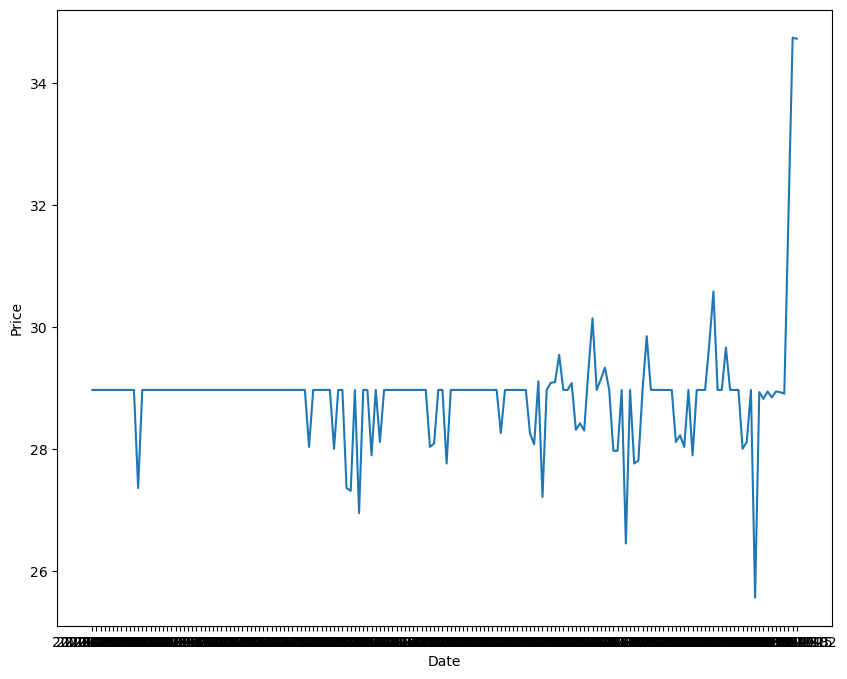

In [806]:
#Plot price changes for least missing values products
fig, ax = plt.subplots( figsize=(10, 8))
sns.lineplot(data = price[price['Product']==8370], x='Date', y='Price', ax = ax)
plt.set_xticks(price[price['Product']==8370].Date)
plt.title('Price changes product 8370')
plt.show()

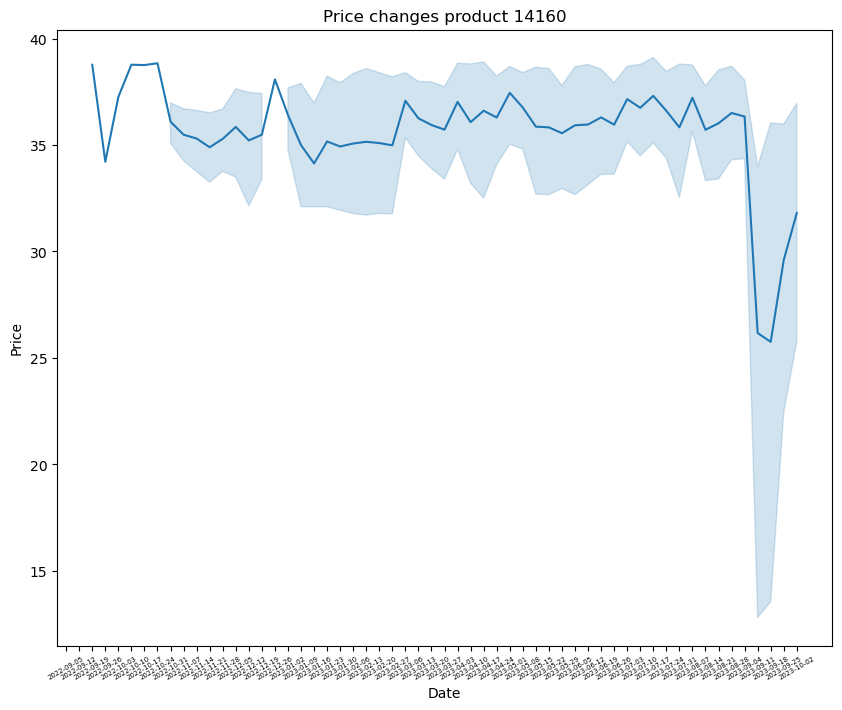

In [767]:
#Plot price changes for least missing values products
fig, ax = plt.subplots( figsize=(10, 8))
sns.lineplot(data = price[price['Product']==14160], x='Date', y='Price', ax = ax)
plt.xticks(fontsize =5 , rotation=30)
plt.title('Price changes product 14160')
plt.show()

In [781]:
price[(price['Product']==14160) & (price['Date']=='2022-12-05')].Price.describe()

count     5.000000
mean     35.850125
std       2.664508
min      31.612000
25%      34.811665
50%      37.448334
75%      37.550000
max      37.828625
Name: Price, dtype: float64

In [791]:
price[(price['Product']==14160) & (price['Date']=='2022-12-05')]

,Client,Warehouse,Product,Date,Price
1896718,0,1,14160,2022-12-05,37.448334
1896886,0,47,14160,2022-12-05,NaN
1896953,0,83,14160,2022-12-05,31.612000
1896987,0,95,14160,2022-12-05,NaN
1897061,0,120,14160,2022-12-05,34.811665
1897123,0,121,14160,2022-12-05,37.828625
1897159,0,123,14160,2022-12-05,NaN
1897198,0,154,14160,2022-12-05,NaN
1897217,0,155,14160,2022-12-05,NaN
1897228,0,161,14160,2022-12-05,NaN


In [803]:
sales[(sales['Warehouse']==47) & (sales['Product']==14160) & (sales['Date']=='2022-12-05') ]

,Client,Warehouse,Product,Date,Sales
1896886,0,47,14160,2022-12-05,0.0


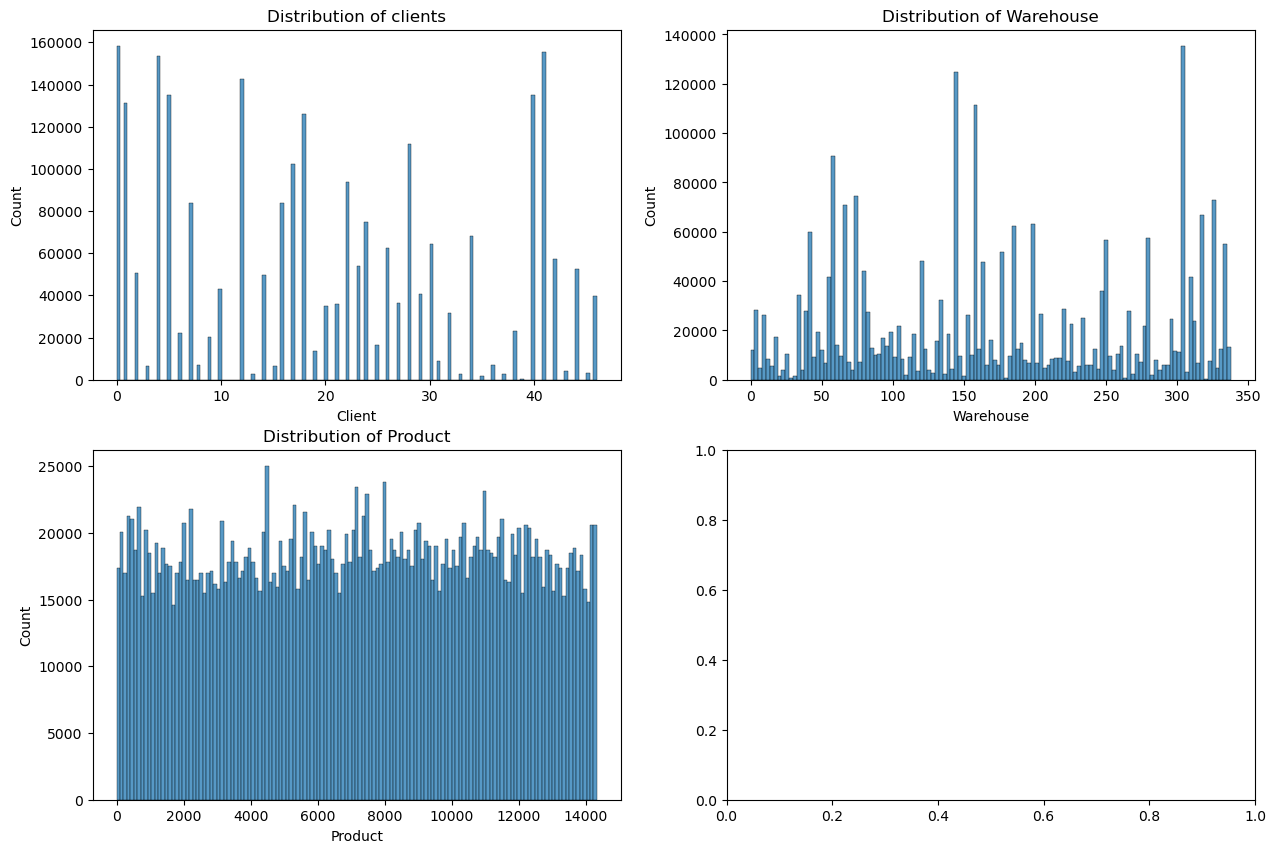

In [212]:
#Plot the distribution of the clients to understand the type of information we are dealing with
#create the figure for all 3 plots
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

#Plot histogram for Client
sns.histplot(data=sales, x = 'Client', ax=ax[0,0])
ax[0, 0].set_title('Distribution of clients')

#Plot histogram for Warehouse
sns.histplot(data=sales, x = 'Warehouse', ax = ax[0,1])
ax[0, 1].set_title('Distribution of Warehouse')

#Plot histogram for Product
sns.histplot(data=sales, x = 'Product', ax = ax[1,0])
ax[1, 0].set_title('Distribution of Product')



plt.show()

In [298]:
#deep dive into clients
sales.Client.sort_values().unique()[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

In [308]:
sales.Client.max()

46

In [300]:
#deep dive into warehouse
sales.Warehouse.sort_values().unique()[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

In [310]:
sales.Warehouse.max()

338

In [302]:
#deep dive into warehouse
sales.Product.sort_values().unique()[:10]

array([ 0,  1,  2,  3,  6,  7,  9, 11, 12, 13], dtype=int64)

In [312]:
sales.Product.max()

14323

From this analysis, we cans see that there seem to be clients from 0 to 46, Warehouse from 0 to 338 and products with some missing between 0 and 14323

In [329]:
#convert Date column to date time
sales.Date = pd.to_datetime(sales.Date)

In [335]:
sales.head()

,Client,Warehouse,Product,Date,Sales
0,0,1,367,2020-07-06,7.0
1,0,1,639,2020-07-06,0.0
2,0,1,655,2020-07-06,21.0
3,0,1,1149,2020-07-06,7.0
4,0,1,1485,2020-07-06,0.0


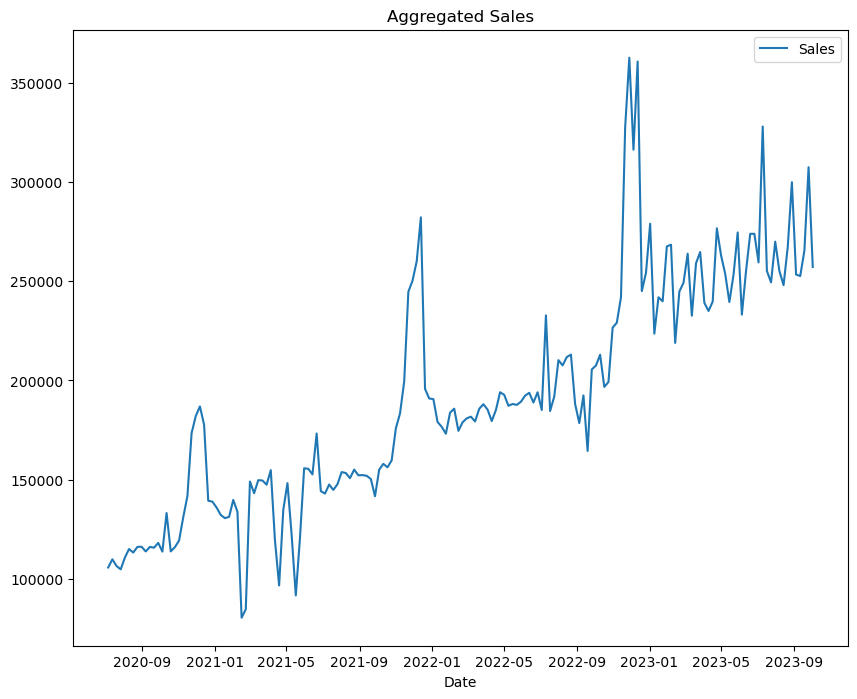

In [347]:
#Plot the original aggregated forecast
fig, ax = plt.subplots(figsize=(10, 8))
sns.lineplot(pd.pivot_table(data=sales, values = 'Sales', index = 'Date', aggfunc='sum'))
ax.set_title('Aggregated Sales')
plt.show()

In [349]:
sales.columns

Index(['Client', 'Warehouse', 'Product', 'Date', 'Sales'], dtype='object')

In [571]:
def plotComponents(df, column, values):
    #Defining function to plot the components that make the total sales, selecting the column and value

    #Agg the data based on sales
    t_df = pd.pivot_table(data=df, values = 'Sales', index = [column, 'Date'], aggfunc='sum').reset_index()
    
    #filter just for the values in the values list
    t_df = t_df[t_df[column].isin(values)]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.lineplot(data=t_df, x='Date', y='Sales', hue=column)
    ax.set_title(f'Sales for {column}s {values}')
    plt.show()

In [419]:
#Identify the % of participation of the client as part of total sales
pd.pivot_table(data = sales[['Client', 'Sales']], index = 'Client', aggfunc='sum').sort_values(by='Sales', ascending=False).head()/sales.Sales.sum()

,Sales
Client,
0,0.259430
41,0.160746
38,0.114242
5,0.059894
42,0.051506


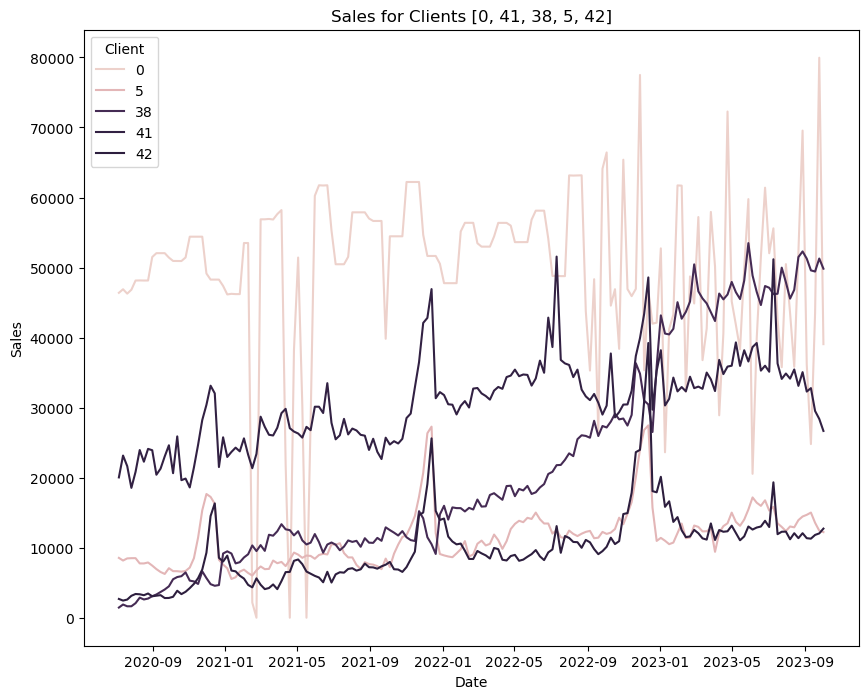

In [579]:
plotComponents(sales, 'Client', [0, 41, 38, 5, 42])

In [425]:
#Identify the % of participation of the Warehouse as part of total sales
pd.pivot_table(data = sales[['Warehouse', 'Sales']], index = 'Warehouse', aggfunc='sum').sort_values(by='Sales', ascending=False).head()/sales.Sales.sum()

,Sales
Warehouse,
3,0.110669
68,0.064299
121,0.050031
2,0.038255
265,0.032623


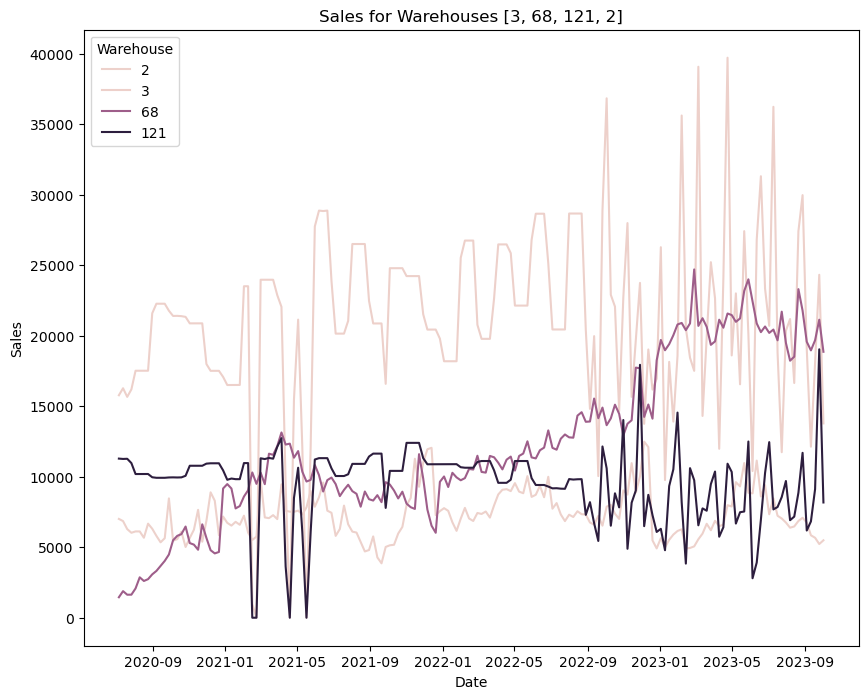

In [583]:
plotComponents(sales, 'Warehouse', [3, 68, 121, 2])

In [433]:
#Identify the % of participation of the Warehouse as part of total sales
pd.pivot_table(data = sales[['Product', 'Sales']], index = 'Product', aggfunc='sum').sort_values(by='Sales', ascending=False).head()/sales.Sales.sum()

,Sales
Product,
2866,0.025420
8986,0.018579
4902,0.016698
1222,0.013555
9410,0.012477


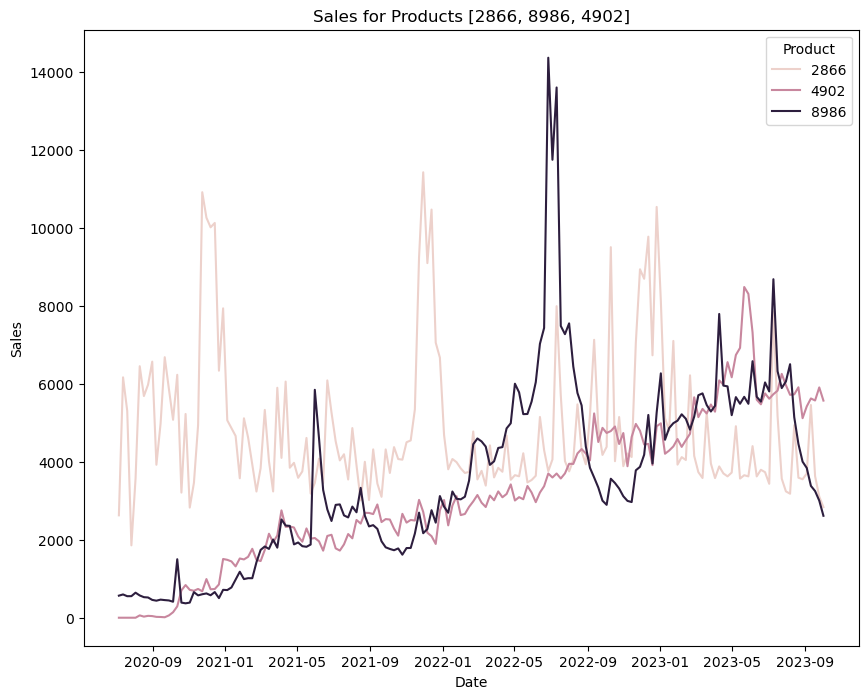

In [585]:
plotComponents(sales, 'Product', [2866, 8986, 4902])

In [587]:
sales.head()

,Client,Warehouse,Product,Date,Sales
0,0,1,367,2020-07-06,7.0
1,0,1,639,2020-07-06,0.0
2,0,1,655,2020-07-06,21.0
3,0,1,1149,2020-07-06,7.0
4,0,1,1485,2020-07-06,0.0


In [589]:
price.head()

,Client,Warehouse,Product,Date,Price
0,0,1,367,2020-07-06,10.900001
1,0,1,639,2020-07-06,NaN
2,0,1,655,2020-07-06,21.343332
3,0,1,1149,2020-07-06,11.480000
4,0,1,1485,2020-07-06,NaN
